# 01 · Exploration: how the pipeline's decisions were made

This notebook is the **investigation trail**. It records the profiling and joins that led to each rule in `src/`. The pipeline itself lives in `src/pipeline.py` and doesn't depend on this notebook.

**To re-run it**, first build the database with `python src/pipeline.py --offline`, then run all cells. Every query reads the SQLite model (`data/processed/skypulse.sqlite`) or the raw snapshot.

In [1]:
import json, sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
con = sqlite3.connect(ROOT / "data/processed/skypulse.sqlite")
FIG = ROOT / "output/figures"; FIG.mkdir(parents=True, exist_ok=True)
q = lambda sql: pd.read_sql(sql, con)

# Chart style: recessive grid/axes, text in ink tokens, thin marks. Two validated categorical slots.
SKYPULSE, DGCA = "#2a78d6", "#eb6834"          # slot 1 blue, slot 2 orange (CVD dE 24.7, validated)
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left", "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110})

## 1. Retrieval: is every source complete?

Every raw file has a manifest entry: URL, retrieval time, row count and sha256. Completeness is checked **per day** for OpenSky, because a partial pull would look like a quiet day.

In [2]:
man = pd.DataFrame(json.loads((ROOT / "data/raw/_manifest.json").read_text())).T
man.groupby("source").agg(files=("rows", "size"), rows=("rows", "sum"), statuses=("status", lambda s: dict(s.value_counts())))

,files,rows,statuses
source,,,
aviationstack,22,1486,{'ok': 22}
dgca,2,164,{'ok': 2}
open_meteo,1,744,{'ok': 1}
opensky,64,21183,{'ok': 64}
ourairports,1,86119,{'ok': 1}


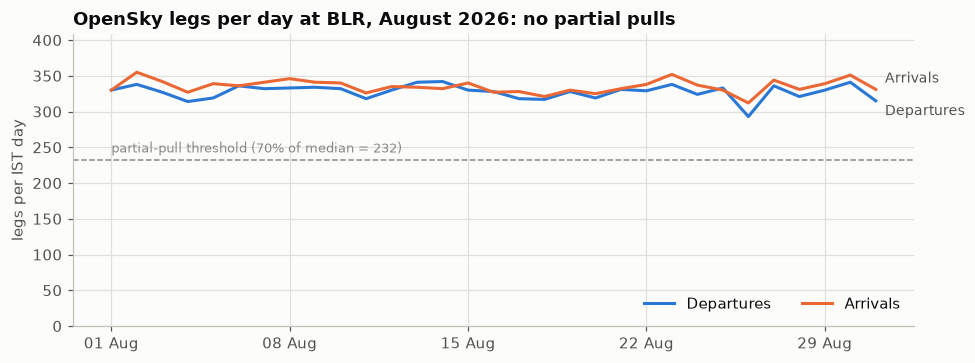

In [3]:
daily = pd.read_csv(ROOT / "data/processed/opensky_daily_counts.csv", parse_dates=["local_day"])
fig, ax = plt.subplots(figsize=(9, 3.4))
import matplotlib.dates as mdates
for d, color, name, dy in (("departure", SKYPULSE, "Departures", -7), ("arrival", DGCA, "Arrivals", 7)):
    s = daily[daily.direction == d]
    ax.plot(s.local_day, s.rows, color=color, lw=2, label=name)
    ax.annotate(name, (s.local_day.iloc[-1], s.rows.iloc[-1]), xytext=(6, dy), textcoords="offset points",
                va="center", color=INK2, fontsize=9)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.SA))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
floor = 0.7 * daily.rows.median()
ax.axhline(floor, color=MUTED, lw=1, ls="--")
ax.annotate(f"partial-pull threshold (70% of median = {floor:.0f})", (daily.local_day.min(), floor), xytext=(0, 5),
            textcoords="offset points", color=MUTED, fontsize=8.5)
ax.set_ylim(0, daily.rows.max() * 1.15); ax.set_ylabel("legs per IST day")
ax.set_title("OpenSky legs per day at BLR, August 2026: no partial pulls")
ax.legend(loc="lower right", ncols=2); fig.tight_layout(); fig.savefig(FIG / "daily_counts.png"); plt.show()

## 2. Profiling OpenSky: what the data cannot tell us

- 43 % of departures have no `estArrivalAirport`: OpenSky lost the aircraft before it landed.
- 527 legs are recorded BLR → BLR. 523 of them are ~5 h round trips where OpenSky missed the outstation stop, and 4 are short circuits; rule V-OS-7 handles both.

In [4]:
o = q("SELECT * FROM stg_opensky WHERE is_crosscheck = 0")
prof = pd.DataFrame({"null %": o.isna().mean().mul(100).round(1), "distinct": o.nunique()})
display(prof[prof["null %"] > 0])
same = o[(o.est_dep_airport == "VOBL") & (o.est_arr_airport == "VOBL")]
print(f"BLR->BLR legs: {len(same)}; median duration {((same.last_seen - same.first_seen) / 60).median():.0f} min; "
      f"airline prefixes: {same.callsign.str[:3].value_counts().head(3).to_dict()}")

,null %,distinct
est_dep_airport,23.8,96
est_arr_airport,21.1,118
dep_horiz_m,23.8,5547
dep_vert_m,23.8,829
arr_horiz_m,21.1,6040
arr_vert_m,21.1,905


BLR->BLR legs: 1054; median duration 306 min; airline prefixes: {'IGO': 584, 'AXB': 328, 'AKJ': 132}


## 3. The join problem: callsign is not the flight number

Matching OpenSky `callsign` directly to AviationStack's flight code gives a schedule for only ~44 % of the 5 groups' departures. Indian carriers use alphanumeric ATC callsigns, so `AIC7JN` operates flight `AIC2810`.

The fix: on the cross-check day, match the **same aircraft (`icao24`) at the same time** in both sources. That match *teaches* the callsign → flight mapping.

In [5]:
xw = q("SELECT * FROM callsign_xwalk")
print(f"{len(xw)} learned pairs; {100 * (1 - xw.same_as_flight_code.mean()):.0f}% of them are callsign != flight code")
display(xw[xw.same_as_flight_code == 0].head(8))
cov = q("""SELECT COALESCE(schedule_source, 'no schedule') AS source, COUNT(*) AS departures
             FROM flight_leg WHERE direction = 'DEP' AND dgca_group IS NOT NULL GROUP BY 1""")
cov["share %"] = (100 * cov.departures / cov.departures.sum()).round(1); cov

489 learned pairs; 47% of them are callsign != flight code


,direction,callsign,op_flight_icao,dt_min,same_as_flight_code
1,ARR,AXB61F,AXB1368,-1.833333,0
2,ARR,AIC9SL,AIC427,-1.533333,0
3,ARR,IGO32AV,IGO6482,-2.100000,0
7,ARR,AXB19H,AXB2019,-1.566667,0
9,ARR,AIC4YR,AIC2853,-2.133333,0
10,ARR,AIC5KH,AIC2865,-2.200000,0
13,ARR,AIC4SW,AIC2632,-1.533333,0
14,ARR,AIC3HK,AIC2863,-1.583333,0


,source,departures,share %
0,callsign_map,2845,32.9
1,flight_code,3778,43.8
2,no schedule,2012,23.3


### Proving AviationStack's time zone (it labels local time as UTC)

If the `+00:00` label were true, matched flights would differ from OpenSky by about −330 min. They differ by about 1 min, so the clock time is IST.

In [6]:
stats = json.loads((ROOT / "data/processed/model_stats.json").read_text())
pd.Series(stats["tz_check"]).to_frame("cross-check")

,cross-check
n,483
median_diff_if_ist_min,0.9
median_diff_if_utc_min,-329.1
iqr_min,3.0
by_direction,"{'ARR': -1.6, 'DEP': 1.4}"
match_rate,"{'DEP': 0.935, 'ARR': 0.859}"


## 4. Delay distribution, and the retimes it exposed

The first cut gave "delayed flights average 110 min late" while the p90 was only 19 min. That meant a fat tail. Flights like `AXB941` were **+666 min on every one of 12 operations** with a 16-min spread: a schedule that changed between August and the September sample, not a delay. Rule **V-DR-5** now detects this signature and excludes those flights. A second pass caught smaller retimes too: flights such as `AIC2511` ran a steady ~40 min late every day in August, yet were on time in the September sample, so their August schedule was different.

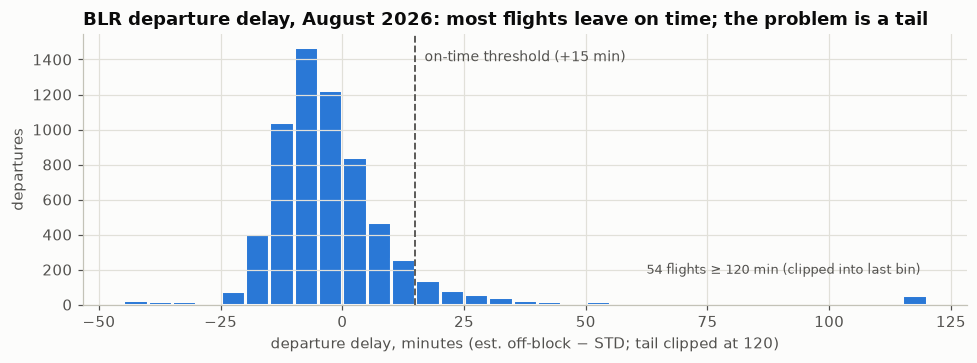

,direction,op_flight_icao,n,med,late,early,iqr,sample_offset_min,reason
16,DEP,AXB941,12,665.7,1.0,0.0,16.5,28.0,large offset
14,DEP,AXB5313,15,652.0,1.0,0.0,28.6,44.0,large offset
12,DEP,AXB2924,23,558.0,1.0,0.0,199.6,34.0,large offset
9,DEP,AXB2001,31,292.5,1.0,0.0,15.2,4.0,large offset
10,DEP,AXB2361,12,228.9,1.0,0.0,6.2,8.0,large offset
4,ARR,AXB2362,7,226.9,1.0,0.0,11.0,-20.0,large offset
19,DEP,LLR517,21,198.1,0.9,0.0,51.0,6.5,large offset
6,ARR,AXB5312,15,187.7,0.9,0.0,141.8,-26.0,large offset


In [7]:
legs = q("SELECT delay_min, retimed, in_kpi FROM flight_leg WHERE direction = 'DEP' AND delay_min IS NOT NULL")
kpi = legs[legs.in_kpi == 1].delay_min.clip(-45, 120)
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(kpi, bins=range(-45, 125, 5), color=SKYPULSE, edgecolor=SURFACE, linewidth=2)
ax.axvline(15, color=INK2, lw=1.2, ls="--")
tail = int((legs[legs.in_kpi == 1].delay_min >= 120).sum())
ax.annotate(f"{tail} flights ≥ 120 min (clipped into last bin)", (120, tail), xytext=(-4, 14), textcoords="offset points",
            ha="right", color=INK2, fontsize=8.5)
ax.annotate("on-time threshold (+15 min)", (15, ax.get_ylim()[1] * 0.9), xytext=(6, 0), textcoords="offset points", color=INK2, fontsize=9)
ax.set_xlabel("departure delay, minutes (est. off-block − STD; tail clipped at 120)"); ax.set_ylabel("departures")
ax.set_title("BLR departure delay, August 2026: most flights leave on time; the problem is a tail")
fig.tight_layout(); fig.savefig(FIG / "delay_distribution.png"); plt.show()
display(pd.DataFrame(stats["retimed"]["codes"]).sort_values("med", ascending=False).head(8))

## 5. The benchmark: SkyPulse vs DGCA, airline by airline

DGCA is independent: it comes from airline self-reporting, where ours is radar-observed. The overall level agrees to within 0.2 points, and **the airline ranking is identical**.

The level depends on one judgment: excluding the retimed flights found in section 4 (V-DR-5). Left in, SkyPulse reads 88.3 % (a 3.7-point gap), but the airline ranking stays identical. `output/benchmark_comparison.md` shows the evidence for each retimed flight code.

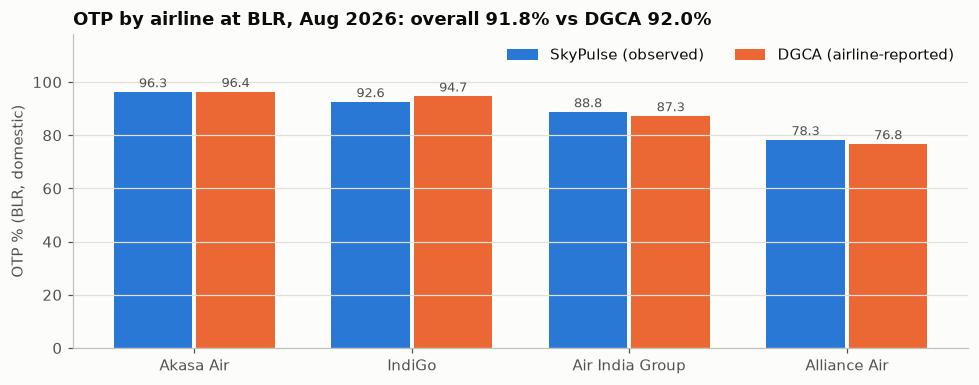

In [8]:
b = json.loads((ROOT / "data/processed/benchmark.json").read_text())
g = pd.DataFrame(b["by_group"]).dropna(subset=["ours", "dgca"]).sort_values("dgca", ascending=False)
fig, ax = plt.subplots(figsize=(9, 3.6)); x = range(len(g)); w = 0.36
bars1 = ax.bar([i - w / 2 - 0.01 for i in x], g.ours, w, color=SKYPULSE, label="SkyPulse (observed)")
bars2 = ax.bar([i + w / 2 + 0.01 for i in x], g.dgca, w, color=DGCA, label="DGCA (airline-reported)")
for bars in (bars1, bars2):
    for r in bars:
        ax.annotate(f"{r.get_height():.1f}", (r.get_x() + r.get_width() / 2, r.get_height()), xytext=(0, 3),
                    textcoords="offset points", ha="center", color=INK2, fontsize=8.5)
ax.set_xticks(list(x), g.dgca_group); ax.set_ylabel("OTP % (BLR, domestic)")
ax.set_ylim(0, 118); ax.set_yticks(range(0, 101, 20))  # bars start at zero; headroom above 100 holds the legend
ax.set_title(f"OTP by airline at BLR, Aug 2026: overall {b['ours_pct']}% vs DGCA {b['dgca_blr_pct']}%")
ax.legend(loc="upper right", ncols=2); ax.grid(axis="x", visible=False)
fig.tight_layout(); fig.savefig(FIG / "otp_vs_dgca.png"); plt.show()

## 6. The one assumption we cannot measure: taxi-out time

OpenSky sees wheels-up; OTP is defined on off-block. The chart shows how OTP moves with the taxi allowance. DGCA's figure is reached at about 16 min; that's a diagnostic and is never used for tuning.

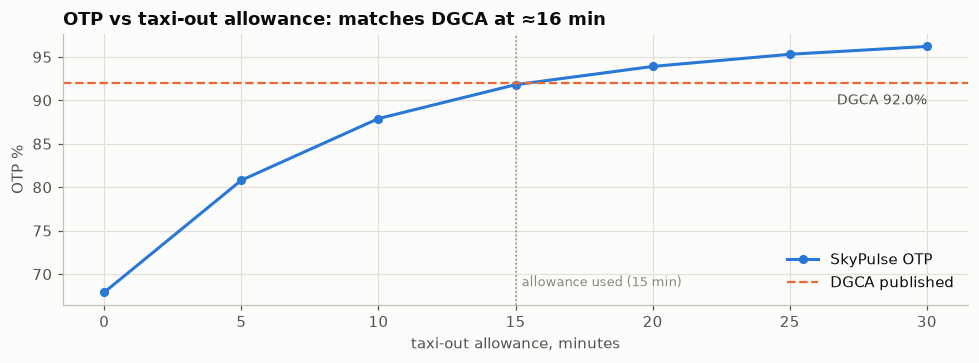

In [9]:
sw = pd.Series(b["sweep"]).rename(index=int).sort_index()
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(sw.index, sw.values, color=SKYPULSE, lw=2, marker="o", ms=5, label="SkyPulse OTP")
ax.axhline(b["dgca_blr_pct"], color=DGCA, lw=1.5, ls="--", label="DGCA published")
ax.annotate(f"DGCA {b['dgca_blr_pct']}%", (sw.index.max(), b["dgca_blr_pct"]), xytext=(0, -14), textcoords="offset points",
            ha="right", color=INK2, fontsize=9)
ax.axvline(15, color=MUTED, lw=1, ls=":")
ax.annotate("allowance used (15 min)", (15, sw.min()), xytext=(4, 4), textcoords="offset points", color=MUTED, fontsize=8.5)
ax.set_xlabel("taxi-out allowance, minutes"); ax.set_ylabel("OTP %")
ax.set_title(f"OTP vs taxi-out allowance: matches DGCA at ≈{b['implied_taxi_out_min']} min")
ax.legend(loc="lower right"); fig.tight_layout(); fig.savefig(FIG / "taxi_sensitivity.png"); plt.show()

## 7. Where delay comes from

The evidence table has the full breakdown. This is the query behind it:

In [10]:
q("""SELECT attribution, COUNT(*) AS delayed_departures,
          ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS share_pct
     FROM departure_outcome WHERE outcome = 'DELAYED' GROUP BY attribution ORDER BY 2 DESC""")

,attribution,delayed_departures,share_pct
0,ground-side / other,292,54.2
1,reactionary (inbound late),153,28.4
2,weather-exposed,67,12.4
3,inbound not observed,27,5.0
